**EDA2**

1. Data Exploration and Preprocessing:
•	Load the dataset and conduct basic data exploration (summary statistics, missing values, data types).
•	Handle missing values as per the best practices (imputation, removal, etc.).
•	Apply scaling techniques to numerical features:
•	Standard Scaling
•	Min-Max Scaling
•	Discuss the scenarios where each scaling technique is preferred and why.




In [108]:
import pandas as pd
import numpy as np

In [109]:
df=pd.read_csv('adult_with_headers.csv')

In [110]:
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [112]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [113]:
df.duplicated().sum()

np.int64(24)

In [114]:
df.drop_duplicates(inplace=True)

In [115]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [116]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

In [117]:
num_df=df.select_dtypes(include='number').columns
num_df

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

In [118]:
num_df_ss=ss.fit_transform(df[num_df])

In [119]:
num_df_ss

array([[ 0.03038995, -1.06356884,  1.13477712,  0.14829174, -0.21674317,
        -0.03566374],
       [ 0.8369732 , -1.00866848,  1.13477712, -0.14597544, -0.21674317,
        -2.22248299],
       [-0.0429358 ,  0.24503992, -0.42067868, -0.14597544, -0.21674317,
        -0.03566374],
       ...,
       [ 1.42357919, -0.35877886, -0.42067868, -0.14597544, -0.21674317,
        -0.03566374],
       [-1.2161478 ,  0.11092955, -0.42067868, -0.14597544, -0.21674317,
        -1.65552985],
       [ 0.9836247 ,  0.92981187, -0.42067868,  1.88763548, -0.21674317,
        -0.03566374]])

In [120]:
from sklearn.preprocessing import MinMaxScaler
mm=MinMaxScaler()
num_min_df=mm.fit_transform(df[num_df])
num_min_df

array([[0.30136986, 0.0443019 , 0.8       , 0.02174022, 0.        ,
        0.39795918],
       [0.45205479, 0.0482376 , 0.8       , 0.        , 0.        ,
        0.12244898],
       [0.28767123, 0.13811345, 0.53333333, 0.        , 0.        ,
        0.39795918],
       ...,
       [0.56164384, 0.09482688, 0.53333333, 0.        , 0.        ,
        0.39795918],
       [0.06849315, 0.12849934, 0.53333333, 0.        , 0.        ,
        0.19387755],
       [0.47945205, 0.18720338, 0.53333333, 0.1502415 , 0.        ,
        0.39795918]])

**2. Encoding Techniques:**
•	Apply One-Hot Encoding to categorical variables with less than 5 categories.
•	Use Label Encoding for categorical variables with more than 5 categories.
•	Discuss the pros and cons of One-Hot Encoding and Label Encoding.

In [121]:
cat_df=df.select_dtypes(include='object').columns
cat_df

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [122]:
ohe_cols=[]
le_cols=[]

for col in cat_df:
    if df[col].nunique()<5:
      ohe_cols.append(col)
    else:
      le_cols.append(col)

print(ohe_cols)
print(le_cols)

['sex', 'income']
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


In [123]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
ohe=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
ohe_encoded_features=ohe.fit_transform(df[ohe_cols])
ohe_features_names=ohe.get_feature_names_out(ohe_cols)
df_ohe=pd.DataFrame(ohe_encoded_features,columns=ohe_features_names,index=df.index)
df=pd.concat([df.drop(columns=ohe_cols),df_ohe],axis=1)

df.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,2174,0,40,United-States,0.0,1.0,1.0,0.0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,0,0,13,United-States,0.0,1.0,1.0,0.0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,0,0,40,United-States,0.0,1.0,1.0,0.0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,40,United-States,0.0,1.0,1.0,0.0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,40,Cuba,1.0,0.0,1.0,0.0


In [125]:
for col in le_cols:
    df[col] = le.fit_transform(df[col])
print(df.head())

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          7   77516          9             13               4   
1   50          6   83311          9             13               2   
2   38          4  215646         11              9               0   
3   53          4  234721          1              7               2   
4   28          4  338409          9             13               2   

   occupation  relationship  race  capital_gain  capital_loss  hours_per_week  \
0           1             1     4          2174             0              40   
1           4             0     4             0             0              13   
2           6             1     4             0             0              40   
3           6             0     2             0             0              40   
4          10             5     2             0             0              40   

   native_country  sex_ Female  sex_ Male  income_ <=50K  income_ >50K  
0            

**3.Feature Engineering:**

• Create at least 2 new features that could be beneficial for the model. Explain the rationale behind your choices.

 • Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice.

In [133]:
df['Total_Capital_Interaction'] = df['capital_gain'] - df['capital_loss']


In [132]:
df['Age_Hours_Interaction'] = df['age'] * df['hours_per_week']


In [128]:
print(df['capital_gain'].skew())
print(df['capital_loss'].skew())
print(df['hours_per_week'].skew())

11.949402833551463
4.592702423271812
0.22875887785250426


In [129]:
df['capital_gain_log'] = np.log1p(df['capital_gain'])
print(f"Skewness of original capital_gain: {df['capital_gain'].skew()}")
print(f"Skewness of log-transformed capital_gain: {df['capital_gain_log'].skew()}")
df.head()

Skewness of original capital_gain: 11.949402833551463
Skewness of log-transformed capital_gain: 3.094666793136126


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,Total_Capital_Interaction,Age_Hours_Interaction,capital_gain_log
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,0.0,1.0,1.0,0.0,2174,1560,7.684784
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,0.0,1.0,1.0,0.0,0,650,0.000000
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,0.0,1.0,1.0,0.0,0,1520,0.000000
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,0.0,1.0,1.0,0.0,0,2120,0.000000
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,1.0,0.0,1.0,0.0,0,1120,0.000000


In [135]:
df['Age_Hours_Interaction_log'] = np.log1p(df['Age_Hours_Interaction'])
print(f"Skewness of original Age_Hours_Interaction: {df['Age_Hours_Interaction'].skew()}")
print(f"Skewness of log-transformed Age_Hours_Interaction: {df['Age_Hours_Interaction_log'].skew()}")

Skewness of original Age_Hours_Interaction: 0.8001434430335914
Skewness of log-transformed Age_Hours_Interaction: -1.2890075593786563


**4.Feature Selection:**

• Use the Isolation Forest algorithm to identify and remove outliers. Discuss how outliers can affect model performance.

• Apply the PPS (Predictive Power Score) to find and discuss the relationships between features. Compare its findings with the correlation matrix.

In [136]:
from sklearn.ensemble import IsolationForest

all_numerical_cols = df.select_dtypes(include=['number']).columns.tolist()


excluded_ohe_cols = ['sex_ Female', 'sex_ Male', 'income_ <=50K', 'income_ >50K']
features_for_iforest = [col for col in all_numerical_cols if col not in excluded_ohe_cols]


iso_forest = IsolationForest(random_state=42)


iso_forest.fit(df[features_for_iforest])

df['outlier_isolation_forest'] = iso_forest.predict(df[features_for_iforest])

print("Isolation Forest applied and outlier column added to DataFrame.")
print(df['outlier_isolation_forest'].value_counts())

Isolation Forest applied and outlier column added to DataFrame.
outlier_isolation_forest
 1    29069
-1     3468
Name: count, dtype: int64


In [137]:
df_cleaned = df[df['outlier_isolation_forest'] == 1].copy()
print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape (after outlier removal): {df_cleaned.shape}")


Original DataFrame shape: (32537, 22)
Cleaned DataFrame shape (after outlier removal): (29069, 22)


Outliers can skew the mean and standard deviation of features, leading to biased model parameters and inaccurate predictions.

Models trained on data containing significant outliers may fit poorly to the majority of the data. This can result in lower accuracy, higher mean squared error (MSE), or poorer generalization on unseen data.

Some algorithms might take longer to converge when outliers are present, as they try to accommodate these extreme values

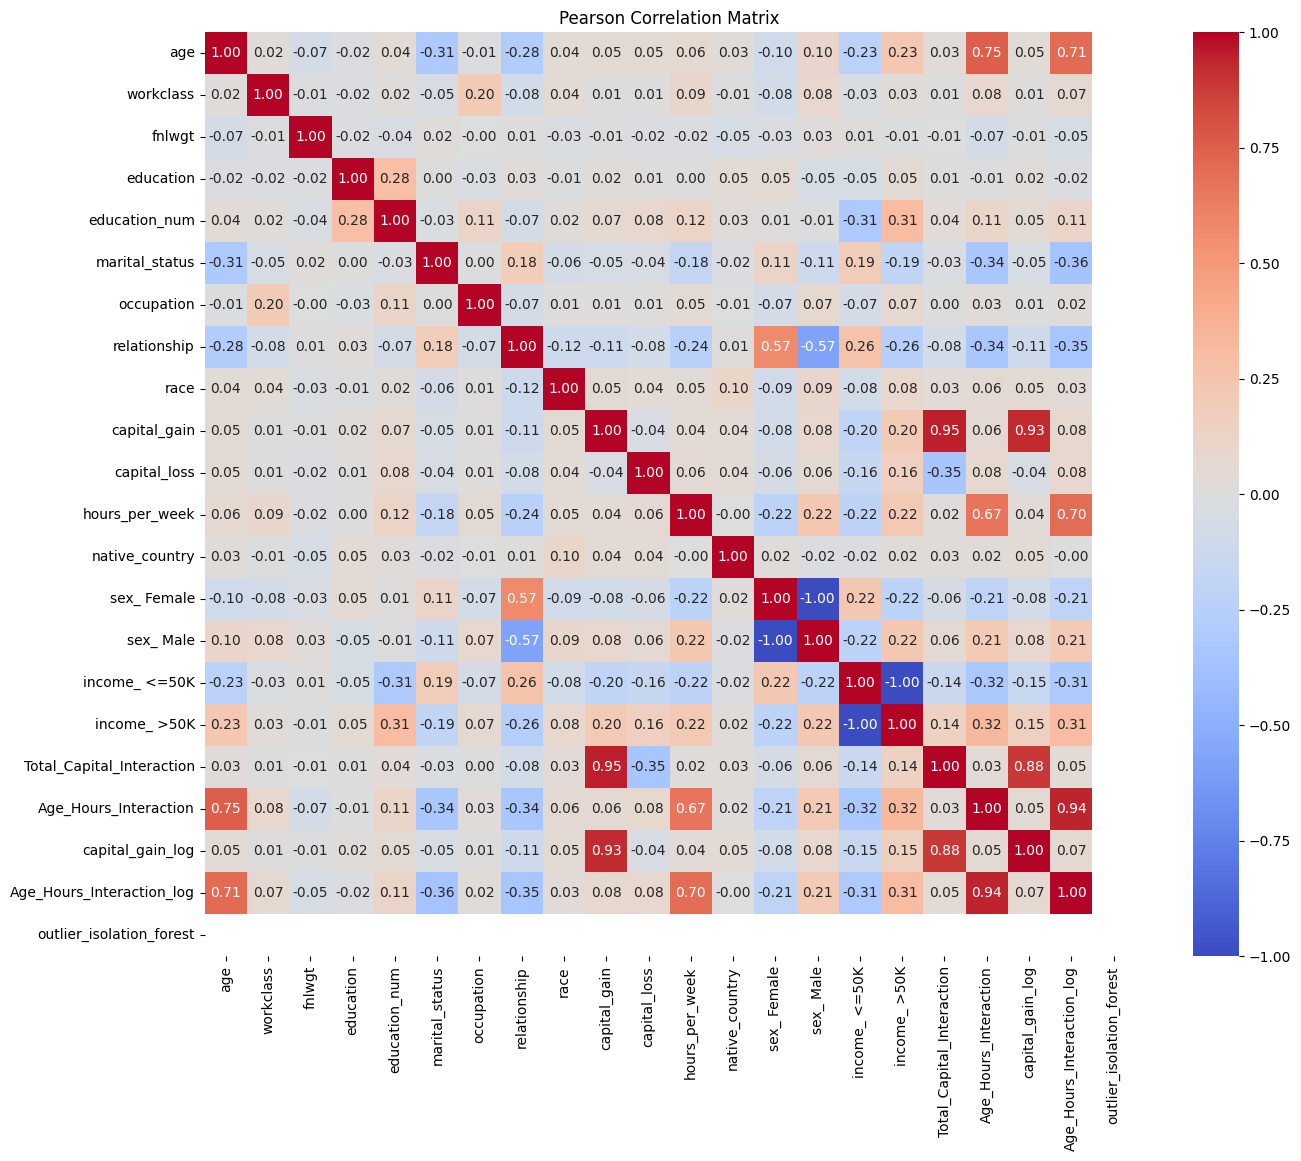

Pearson Correlation matrix calculated and visualized.


In [148]:
import matplotlib.pyplot as plt
import seaborn as sns


correlation_matrix = df_cleaned.corr(numeric_only=True)

# Plotting the Correlation matrix
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix')
plt.show()




**Note: The Predictive Power Score (PPS) could not be calculated due to persistent installation errors with the 'ppscore' library in this environment. **